# T008 · 蛋白质数据获取：蛋白质数据库 (PDB)

**注意：** 本教程是 TeachOpenCADD 的一部分，该平台旨在教授特定领域技能，并为研究项目提供管道模板作为起点。

作者：

- Calvinna Caswara, CADD seminar, 2017, Charité/FU Berlin
- Dora Vuckovic, CADD seminar, 2018, Charité/FU Berlin
- Dominique Sydow, 2019-2020, [Volkamer lab, Charité](https://volkamerlab.org/)
- Andrea Volkamer, 2020, [Volkamer lab, Charité](https://volkamerlab.org/)
- Yonghui Chen, 2020, [Volkamer lab, Charité](https://volkamerlab.org/)

__教程 T008__：本教程是首篇 TeachOpenCADD 出版物中描述的 TeachOpenCADD 流程的一部分，包括 T001-T010 教程。

## 本教程目标

在本教程中，我们将为下一个教程做基础工作——在下一个教程中，我们将生成基于配体的药效团。为此，我们将从 PDB 中查询蛋白质-配体复合物，以提取感兴趣的配体。

### 理论内容

* 蛋白质数据库（PDB）
* 使用 Python 包 `biotite` 和 `pypdb` 查询 PDB

### 实践内容

* 选择一个查询蛋白质
* 获取查询蛋白质的 PDB 条目数量
* 查找满足特定条件的 PDB 条目
* 选择最高分辨率的 PDB 条目
* 从顶部结构中获取配体的元数据
* 绘制顶部配体分子
* 创建蛋白质-配体 ID 对
* 对齐 PDB 结构并提取配体

### 参考文献

* 蛋白质数据库（[PDB website](http://www.rcsb.org/)）
* `pypdb` Python 包（[_Bioinformatics_ (2016), **32**, 159-60](https://academic.oup.com/bioinformatics/article-lookup/doi/10.1093/bioinformatics/btv543)）
* `biotite` Python 包（[documentation](https://www.biotite-python.org/examples/index.html)）
* PDB 中的蛋白质结构（[PDB101](http://pdb101.rcsb.org/learn/guide-to-understanding-pdb-data/introduction)）
* 关于 PDB 文件格式的信息（[PDB101](http://pdb101.rcsb.org/learn/guide-to-understanding-pdb-data/dealing-with-coordinates)）

In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install teachopencadd --no-deps -q
    !teachopencadd -d 8
    %pip uninstall teachopencadd -y -q
    %pip install -qr requirements.txt

## 理论

### 蛋白质数据库（PDB）

RCSB 蛋白质数据库（PDB）是一个全面的结构生物学信息数据库。蛋白质、蛋白质-配体、蛋白质-蛋白质、蛋白质-DNA/RNA 复合物等原子级大分子结构储存在该数据库中。PDB 中所有结构均已通过实验测定，主要方法包括 [X 射线晶体学](https://pdb101.rcsb.org/learn/guide-to-understanding-pdb-data/methods-for-determining-structure#xray)、[核磁共振波谱](https://pdb101.rcsb.org/learn/guide-to-understanding-pdb-data/methods-for-determining-structure#nmr) 以及最近发展起来的 [低温电子显微镜](https://pdb101.rcsb.org/learn/guide-to-understanding-pdb-data/methods-for-determining-structure#cryo)。

### 使用 Python 包 `biotite` 和 `pypdb` 查询 PDB

PDB 数据库中的每个结构都链接到许多不同的字段以保存元信息。查看[PDB 中可用字段的完整列表](https://search.rcsb.org/structure-search-attributes.html)。

在本教程中，我们将使用两个 Python 包来搜索和获取来自 PDB 的数据。

1. `biotite`：与 PDB 接口交互，搜索满足我们要求的条目
2. `pypdb`：获取所选 PDB 条目列表的元信息以及 PDB 结构文件

`biotite` 和 `pypdb` 都只是 Python 包，它们在后台使用 PDB [REST API](http://www.rcsb.org/pdb/software/rest.do)，根据官方 PDB 文档。

PDB 数据库中的每个结构都链接到许多不同的字段以保存元信息。查看 RCSB 网站上[化学物质](https://search.rcsb.org/chemical-search-attributes.html)/[结构](https://search.rcsb.org/structure-search-attributes.html)可用字段和支持运算符的完整列表。Python 包 `biotite` 提供了便捷的模块 `databases.rcsb`（参见[文档](https://www.biotite-python.org/apidoc/biotite.database.rcsb.html)），允许我们查询其中一个（`FieldQuery`，参见[文档](https://www.biotite-python.org/apidoc/biotite.database.rcsb.FieldQuery.html#biotite.database.rcsb.FieldQuery)）或多个（`CompositeQuery`，参见[文档](https://www.biotite-python.org/apidoc/biotite.database.rcsb.CompositeQuery.html#biotite.database.rcsb.CompositeQuery)）字段，以检索匹配我们条件的 PDB ID 的计数（`count`）或列表（`search`）。

Python 包 `pypdb` 为 PDB 提供了一个接口，不仅可以查询 PDB ID，还可以下载相关的元数据和结构文件（[_Bioinformatics_ (2016), **1**, 159-60](https://academic.oup.com/bioinformatics/article-lookup/doi/10.1093/bioinformatics/btv543)，[文档](http://www.wgilpin.com/pypdb_docs/html/)）。请查看介绍 `pypdb` API 的[演示](https://github.com/williamgilpin/pypdb/blob/master/demos/demos.ipynb) notebook。

我们将在本 notebook 中使用这两个包：`biotite` 用于根据特定条件快速筛选 PDB 中的众多结构，`pypdb` 用于下载感兴趣的特定 PDB 条目的元数据和结构文件。

## 实践

In [2]:
import collections
import logging
import pathlib
import time
import warnings
import datetime

import pandas as pd
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
import requests
from tqdm.auto import tqdm
import redo
import requests_cache
import nglview
import pypdb
import biotite.database.rcsb as rcsb
from rdkit.Chem import Draw
from rdkit.Chem import PandasTools

from opencadd.structure.superposition.api import align, METHODS
from opencadd.structure.core import Structure

# Disable some unneeded warnings
logger = logging.getLogger("opencadd")
logger.setLevel(logging.ERROR)
warnings.filterwarnings("ignore")

# Cache requests -- this will speed up repeated queries to PDB
requests_cache.install_cache("rcsb_pdb", backend="memory")

In [3]:
# Define paths
HERE = pathlib.Path(_dh[-1])
DATA = HERE / "data"

### 选择一个查询蛋白质

我们使用 EGFR 作为本教程的查询蛋白质。EGFR 的 UniProt ID 是 `P00533`，对应于基因名称 `EGFR`。这可以从 [UniProt 网站](https://www.uniprot.org/uniprot/P00533) 获取。

In [4]:
uniprot_id = "P00533"

### 获取查询蛋白质的 PDB 条目数量

PDB 中有多少 EGFR 结构可用（在本 notebook 最后一次运行时）？

In [5]:
query_by_uniprot_id = rcsb.FieldQuery(
    "rcsb_polymer_entity_container_identifiers.reference_sequence_identifiers.database_accession",
    exact_match=uniprot_id,
)
today = datetime.datetime.now()
print(
    f"Number of structures on {today.year}-{today.month}-{today.day}: {rcsb.count(query_by_uniprot_id)}"
)

Number of structures on 2026-4-21: 385


自 [1971 年 PDB 建立](https://www.rcsb.org/pages/about-us/history)以来，每年有多少结构可用？

In [6]:
# Define lists for years and number of structures available in a given year
years = range(1971, datetime.datetime.now().year)
n_structures = []

for year in years:
    # Set latest date for allowed deposition
    before_deposition_date = f"{year}-12-31T23:59:59Z"
    # Set up query for structures deposited latest at given date
    query_by_deposition_date = rcsb.FieldQuery(
        "rcsb_accession_info.deposit_date", less_or_equal=before_deposition_date
    )
    # Set up combined query
    query = rcsb.CompositeQuery(
        [query_by_uniprot_id, query_by_deposition_date],
        "and",
    )
    # Count matching structures and add to list
    n_structures.append(rcsb.count(query))
    # wait shortly to not overload the API
    time.sleep(0.1)

绘制结果！

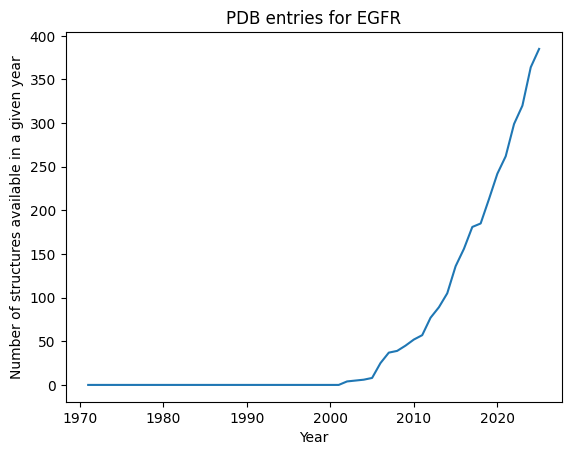

In [7]:
plt.plot(years, n_structures)
plt.title("PDB entries for EGFR")
plt.xlabel("Year")
plt.ylabel("Number of structures available in a given year");

### 查找满足特定条件的 PDB 条目

我们将搜索 PDB 中描述满足以下条件的结构的 PDB ID：EGFR 与配体复合，通过 X 射线晶体学解析，分辨率 ≤ 3.0 Å。由于我们希望蛋白质在结构上与结合口袋尽可能相似，我们还将选择包含一条链的蛋白质，以避免由同源或异源多聚体引起的构象变化。

我们再次使用 `biotite` 包，基于以下组合查询搜索 PDB ID：

| 字段 | 运算符 | 值 |
|------|--------|--------|
| `rcsb_polymer_entity_container_identifiers.reference_sequence_identifiers.database_accession` | `exact_match` | `P00533` |
| `rcsb_polymer_entity_container_identifiers.reference_sequence_identifiers.database_name` | `exact_match` | `UniProt` |
| `exptl.method` | `exact_match` | `X-RAY DIFFRACTION` |
| `rcsb_entry_info.resolution_combined` | `less_or_equal` | 3.0 |
| `rcsb_entry_info.deposited_polymer_entity_instance_count` | `equals` | 1 |

我们定义我们的条件。

In [8]:
uniprot_id = "P00533"
before_deposition_date = "2020-01-01T00:00:00Z"
experimental_method = "X-RAY DIFFRACTION"
max_resolution = 3.0
n_chains = 1
min_ligand_molecular_weight = 100.0

我们设置每个查询。

In [9]:
query_by_uniprot_id = rcsb.FieldQuery(
    "rcsb_polymer_entity_container_identifiers.reference_sequence_identifiers.database_accession",
    exact_match=uniprot_id,
)
query_by_deposition_date = rcsb.FieldQuery(
    "rcsb_accession_info.deposit_date", less=before_deposition_date
)
query_by_experimental_method = rcsb.FieldQuery("exptl.method", exact_match=experimental_method)
query_by_resolution = rcsb.FieldQuery(
    "rcsb_entry_info.resolution_combined", less_or_equal=max_resolution
)
query_by_polymer_count = rcsb.FieldQuery(
    "rcsb_entry_info.deposited_polymer_entity_instance_count", equals=n_chains
)
query_by_ligand_mw = rcsb.FieldQuery(
    "chem_comp.formula_weight", molecular_definition=True, greater=min_ligand_molecular_weight
)

我们单独执行每个查询并检查每个条件的匹配数。

In [10]:
print(f"Number of structures with UniProt ID {uniprot_id}: {rcsb.count(query_by_uniprot_id)}")
time.sleep(0.1)  # wait shortly to not overload the API
print(
    f"Number of structures deposited before {before_deposition_date}: {rcsb.count(query_by_deposition_date)}"
)
time.sleep(0.1)
print(
    f"Number of structures resolved by {experimental_method}: {rcsb.count(query_by_experimental_method)}"
)
time.sleep(0.1)
print(
    f"Number of structures with resolution less than or equal to {max_resolution}: {rcsb.count(query_by_resolution)}"
)
time.sleep(0.1)
print(f"Number of structures with only {n_chains} chain: {rcsb.count(query_by_polymer_count)}")
time.sleep(0.1)
print(
    f"Number of structures with ligand of more than or equal to {min_ligand_molecular_weight} Da: {rcsb.count(query_by_ligand_mw)}"
)

Number of structures with UniProt ID P00533: 385
Number of structures deposited before 2020-01-01T00:00:00Z: 166264
Number of structures resolved by X-RAY DIFFRACTION: 203558
Number of structures with resolution less than or equal to 3.0: 201385
Number of structures with only 1 chain: 86880
Number of structures with ligand of more than or equal to 100.0 Da: 252475


我们使用 `and` 运算符组合所有查询，以仅匹配满足所有条件的 PDB ID。

In [11]:
query = rcsb.CompositeQuery(
    [
        query_by_uniprot_id,
        query_by_deposition_date,
        query_by_experimental_method,
        query_by_resolution,
        query_by_polymer_count,
        query_by_ligand_mw,
    ],
    "and",
)
pdb_ids = rcsb.search(query)
print(f"Number of matches: {len(pdb_ids)}")
print("Selected PDB IDs:")
print(*pdb_ids)

Number of matches: 110
Selected PDB IDs:
2GS2 2ITN 2ITQ 2ITV 2ITZ 2J5F 3VJO 3W2Q 3W2R 3W32 4I22 4I23 4JQ7 4RJ8 4WKQ 5C8N 5CAO 5EDP 5EDQ 5EM5 5EM6 5HG5 5HG8 5HIC 5U8L 5UG9 5UGC 5X28 5ZTO 5ZWJ 6JWL 6JXT 6S89 6S8A 6S9C 1M17 2ITT 2ITX 3UG1 3UG2 3W2O 3W2P 3W2S 4I1Z 4JR3 4LI5 4LQM 4RJ4 4RJ6 4WRG 4ZAU 5C8K 5CAL 5CAN 5CAP 5CAS 5CAU 5CAV 5EDR 5EM7 5FED 5FEE 5HCY 5X27 5XDL 5XGM 6JRJ 6JRK 6JRX 6JZ0 6S9D 1M14 1XKK 2EB2 2EB3 2ITP 2ITU 2ITW 2RGP 3BEL 3GOP 3POZ 3VJN 3W33 4G5J 4HJO 4JQ8 4JRV 4RJ7 5C8M 5CAQ 5EM8 5GMP 5GNK 5GTZ 5HCX 5HCZ 5HG7 5HG9 5HIB 5J9Y 5J9Z 5UG8 5UGA 5UGB 5X26 5XDK 6D8E 6JX0 6JX4


### 选择最高分辨率的 PDB 条目

到目前为止，我们已经使用特定的搜索条件找到感兴趣的 PDB 条目。

目前，我们无法直接从 `biotite` 获取结构信息（如分辨率），因此我们使用 `pypdb` 包获取 PDB 元数据。此外，我们将从中提取分辨率信息，以选择最高分辨率的 PDB 条目。

In [12]:
@redo.retriable(attempts=10, sleeptime=2)
def describe_one_pdb_id(pdb_id):
    """Fetch meta information from PDB."""
    described = pypdb.describe_pdb(pdb_id)
    if described is None:
        print(f"! Error while fetching {pdb_id}, retrying ...")
        raise ValueError(f"Could not fetch PDB id {pdb_id}")
    return described

In [13]:
pdbs_data = [describe_one_pdb_id(pdb_id) for pdb_id in tqdm(pdb_ids)]

  0%|          | 0/110 [00:00<?, ?it/s]

让我们看看前几个 PDB ID 的元数据（仅键名，因为字典包含大量信息）。

In [14]:
print("\n".join(pdbs_data[0].keys()))

audit_author
cell
citation
database_2
diffrn
diffrn_detector
diffrn_radiation
diffrn_source
entry
exptl
exptl_crystal
exptl_crystal_grow
pdbx_audit_revision_category
pdbx_audit_revision_details
pdbx_audit_revision_group
pdbx_audit_revision_history
pdbx_audit_revision_item
pdbx_database_related
pdbx_database_status
pdbx_initial_refinement_model
pdbx_vrpt_summary
pdbx_vrpt_summary_diffraction
pdbx_vrpt_summary_geometry
rcsb_accession_info
rcsb_entry_container_identifiers
rcsb_entry_info
rcsb_primary_citation
refine
refine_hist
refine_ls_restr
reflns
reflns_shell
software
struct
struct_keywords
symmetry
rcsb_id


让我们更仔细地查看两个我们将感兴趣的键：包含 PDB ID 的 `"entry"` 键（`"id"`）和包含分辨率的 `"rcsb_entry_info"` 键（`"resolution_combined"`）。

In [15]:
pdbs_data[0]["entry"]

{'id': '2GS2'}

In [16]:
pdbs_data[0]["rcsb_entry_info"]

{'assembly_count': 1,
 'branched_entity_count': 0,
 'cis_peptide_count': 0,
 'deposited_atom_count': 2443,
 'deposited_deuterated_water_count': 0,
 'deposited_hydrogen_atom_count': 0,
 'deposited_model_count': 1,
 'deposited_modeled_polymer_monomer_count': 305,
 'deposited_nonpolymer_entity_instance_count': 0,
 'deposited_polymer_entity_instance_count': 1,
 'deposited_polymer_monomer_count': 330,
 'deposited_solvent_atom_count': 24,
 'deposited_unmodeled_polymer_monomer_count': 25,
 'diffrn_radiation_wavelength_maximum': 1.116,
 'diffrn_radiation_wavelength_minimum': 1.116,
 'disulfide_bond_count': 0,
 'entity_count': 2,
 'experimental_method': 'X-ray',
 'experimental_method_count': 1,
 'inter_mol_covalent_bond_count': 0,
 'inter_mol_metalic_bond_count': 0,
 'molecular_weight': 37.56,
 'na_polymer_entity_types': 'Other',
 'nonpolymer_entity_count': 0,
 'polymer_composition': 'homomeric protein',
 'polymer_entity_count': 1,
 'polymer_entity_count_DNA': 0,
 'polymer_entity_count_RNA': 0,

现在我们将每个 PDB ID 的分辨率保存为 `pandas` DataFrame，按分辨率升序排序。

In [17]:
resolution = pd.DataFrame(
    [
        [pdb_data["entry"]["id"], pdb_data["rcsb_entry_info"]["resolution_combined"][0]]
        for pdb_data in pdbs_data
    ],
    columns=["pdb_id", "resolution"],
).sort_values(by="resolution", ignore_index=True)
resolution

,pdb_id,resolution
0,5UG9,1.330
1,5HG8,1.420
2,5UG8,1.460
3,3POZ,1.500
4,5HG5,1.520
...,...,...
105,2ITX,2.980
106,5GTZ,2.999
107,2J5F,3.000
108,5C8K,3.000


### 从顶部结构中获取配体的元数据

In [18]:
top_num = 6  # Number of top structures

在下一个教程中，我们将从具有最高分辨率和原子组成配体的前 `top_num` 个结构中构建基于配体的药效团。因此，我们需要获取这些配体的元数据。

In [19]:
selected_pdb_ids = resolution[:top_num]["pdb_id"].to_list()
print(f"Selected PDB IDs: {selected_pdb_ids}")

Selected PDB IDs: ['5UG9', '5HG8', '5UG8', '3POZ', '5HG5', '5UGC']


选定的最高分辨率 PDB 条目可能包含靶向不同结合位点的配体，例如变构和正构结合位点。为了本教程的目的，我们通过仅选择 EGFR 的共晶化配体来缩小我们的选择范围，这些配体呈现_正构_结合位点，即结合口袋主要由残基 Met769（与 ATP 的腺嘌呤部分形成氢键）定义。由于该残基在不同激酶中是保守的，配体与 Met769 的接近程度对识别共晶化配体是高度区分性的。

In [20]:
selected_pdb_ids = ["5UG9", "5HG8", "5UG8", "5UGC"]
print(f"Selected PDB IDs (frozen set): {selected_pdb_ids}")

Selected PDB IDs (frozen set): ['5UG9', '5HG8', '5UG8', '5UGC']


我们使用 `get_ligands` 获取前 `top_num` 个配体的 PDB 信息，并将其存储为 *csv* 文件（作为字典）。

In [21]:
def get_ligands(pdb_id):
    """
    RCSB has not provided a new endpoint for ligand information yet. As a
    workaround we are obtaining extra information from ligand-expo.rcsb.org,
    using HTML parsing. Check Talktorial T011 for more info on this technique!
    """
    pdb_info = _fetch_pdb_nonpolymer_info(pdb_id)
    ligand_expo_ids = [
        nonpolymer_entities["pdbx_entity_nonpoly"]["comp_id"]
        for nonpolymer_entities in pdb_info["data"]["entry"]["nonpolymer_entities"]
    ]

    ligands = {}
    for ligand_expo_id in ligand_expo_ids:
        ligand_expo_info = _fetch_ligand_expo_info(ligand_expo_id)
        ligands[ligand_expo_id] = ligand_expo_info

    return ligands


def _fetch_pdb_nonpolymer_info(pdb_id):
    """
    Fetch nonpolymer data from rcsb.org.
    Thanks @BJWiley233 and Rachel Green for this GraphQL solution.
    """
    query = """{
          entry(entry_id: "%s") {
            nonpolymer_entities {
              pdbx_entity_nonpoly {
                comp_id
                name
                rcsb_prd_id
              }
            }
          }
        }""" % pdb_id

    query_url = f"https://data.rcsb.org/graphql?query={query}"
    response = requests.get(query_url)
    response.raise_for_status()
    info = response.json()
    return info


def _fetch_ligand_expo_info(ligand_id):
    """
    Fetch ligand data from RCSB API using the exact JSON structure
    provided for identifiers like 8AM.
    """
    url = f"https://data.rcsb.org/rest/v1/core/chemcomp/{ligand_id.upper()}"
    r = requests.get(url)

    if r.status_code != 200:
        return {}

    data = r.json()
    chem = data.get("chem_comp", {})
    rcsb_desc = data.get("rcsb_chem_comp_descriptor", {})

    if isinstance(rcsb_desc, list):
        inchi = next(
            (item.get("descriptor") for item in rcsb_desc if item.get("type") == "InChI"), None
        )
        inchikey = next(
            (item.get("descriptor") for item in rcsb_desc if item.get("type") == "InChIKey"), None
        )
        smiles = next(
            (item.get("descriptor") for item in rcsb_desc if "SMILES" in item.get("type", "")),
            None,
        )
    else:
        inchi = rcsb_desc.get("in_ch_i")
        inchikey = rcsb_desc.get("in_ch_ikey")
        smiles = rcsb_desc.get("smilesstereo")

    if not smiles:
        pdbx_descs = data.get("pdbx_chem_comp_descriptor", [])
        for d in pdbx_descs:
            if d.get("program") == "OpenEye OEToolkits" and d.get("type") == "SMILES_CANONICAL":
                smiles = d.get("descriptor")

    return {
        "Name": chem.get("name"),
        "Formula": chem.get("formula"),
        "Molecular weight": chem.get("formula_weight"),
        "Formal charge": chem.get("pdbx_formal_charge"),
        "Atom count": data.get("rcsb_chem_comp_info", {}).get("atom_count"),
        "Chiral atom count": data.get("rcsb_chem_comp_info", {}).get("atom_count_chiral"),
        "Bond count": data.get("rcsb_chem_comp_info", {}).get("bond_count"),
        "Aromatic bond count": data.get("rcsb_chem_comp_info", {}).get("bond_count_aromatic"),
        "Component type": chem.get("type"),
        # Set keys
        "InChI descriptor": inchi,
        "InChIKey descriptor": inchikey,
        "Stereo SMILES (OpenEye)": smiles,
    }

In [22]:
columns = [
    "@structureId",
    "@chemicalID",
    "@type",
    "@molecularWeight",
    "chemicalName",
    "formula",
    "InChI",
    "InChIKey",
    "smiles",
]
rows = []
for pdb_id in selected_pdb_ids:
    ligands = get_ligands(pdb_id)
    # If several ligands contained, take largest (first in results)
    ligand_id, properties = max(ligands.items(), key=lambda kv: kv[1]["Molecular weight"])
    rows.append(
        [
            pdb_id,
            ligand_id,
            properties["Component type"],
            properties["Molecular weight"],
            properties["Name"],
            properties["Formula"],
            properties["InChI descriptor"],
            properties["InChIKey descriptor"],
            properties["Stereo SMILES (OpenEye)"],
        ]
    )

In [23]:
# NBVAL_CHECK_OUTPUT
# Change the format to DataFrame
ligands = pd.DataFrame(rows, columns=columns)
ligands

,@structureId,@chemicalID,@type,@molecularWeight,chemicalName,formula,InChI,InChIKey,smiles
0,5UG9,8AM,non-polymer,445.494,"N-[(3R,4R)-4-fluoro-1-{6-[(3-methoxy-1-methyl-...",C20 H28 F N9 O2,None,None,CCC(=O)N[C@@H]1CN(C[C@H]1F)c2nc(c3c(n2)n(cn3)C...
1,5HG8,634,non-polymer,377.400,N-[3-({2-[(1-methyl-1H-pyrazol-4-yl)amino]-7H-...,C19 H19 N7 O2,None,None,CCC(=O)Nc1cccc(c1)Oc2c3cc[nH]c3nc(n2)Nc4cnn(c4)C
2,5UG8,8BP,non-polymer,415.468,"N-[(3R,4R)-4-fluoro-1-{6-[(1-methyl-1H-pyrazol...",C19 H26 F N9 O,None,None,CCC(=O)N[C@@H]1CN(C[C@H]1F)c2nc(c3c(n2)n(cn3)C...
3,5UGC,8BS,non-polymer,417.441,"N-[(3R,4R)-4-fluoro-1-{6-[(3-methoxy-1-methyl-...",C18 H24 F N9 O2,None,None,CCC(=O)N[C@@H]1CN(C[C@H]1F)c2nc(c3c(n2)n(cn3)C...


In [24]:
ligands.to_csv(DATA / "PDB_top_ligands.csv", header=True, index=False)

### 绘制顶部配体分子

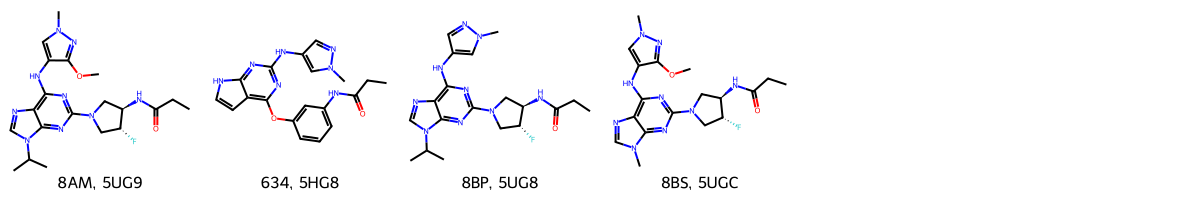

In [25]:
PandasTools.AddMoleculeColumnToFrame(ligands, "smiles")
Draw.MolsToGridImage(
    mols=list(ligands.ROMol),
    legends=list(ligands["@chemicalID"] + ", " + ligands["@structureId"]),
    molsPerRow=top_num,
)

### 创建蛋白质-配体 ID 对

In [26]:
# NBVAL_CHECK_OUTPUT
pairs = collections.OrderedDict(zip(ligands["@structureId"], ligands["@chemicalID"]))
pairs

OrderedDict([('5UG9', '8AM'),
             ('5HG8', '634'),
             ('5UG8', '8BP'),
             ('5UGC', '8BS')])

### 对齐 PDB 结构并提取配体

由于我们想在下一个教程中构建基于配体的药效团，我们需要提取配体的 3D 坐标，以便它们在相同的坐标空间中。为此，我们获取 PDB 结构文件，提取蛋白质和配体，在所有结构上对齐蛋白质，并提取（现在对齐的）配体。

#### 获取 PDB 结构文件

我们现在获取 PDB 结构文件，即蛋白质、配体（以及其他伪影，如水分子和离子）的 3D 坐标。

In [27]:
# Download PDB structures
structures = [Structure.from_pdbid(pdb_id) for pdb_id in pairs]
structures

[<Universe with 2664 atoms>,
 <Universe with 2716 atoms>,
 <Universe with 2632 atoms>,
 <Universe with 2542 atoms>]

#### 提取蛋白质和配体

从结构中提取蛋白质和配体，以去除溶剂和其他伪影。

In [28]:
complexes = [
    Structure.from_atomgroup(structure.select_atoms(f"protein or resname {ligand}"))
    for structure, ligand in zip(structures, pairs.values())
]
complexes

[<Universe with 2330 atoms>,
 <Universe with 2491 atoms>,
 <Universe with 2319 atoms>,
 <Universe with 2320 atoms>]

In [29]:
# Write complex to file
for complex_, pdb_id in zip(complexes, pairs.keys()):
    complex_.write(DATA / f"{pdb_id}.pdb")

#### 对齐蛋白质

（基于蛋白质原子）对齐复合物。

In [30]:
results = align(complexes, method=METHODS["mda"])

`nglview` 可用于在 Jupyter notebook 中可视化分子数据。通过下一个单元格，我们将可视化我们对齐的蛋白质。

In [31]:
view = nglview.NGLWidget()
for complex_ in complexes:
    view.add_component(complex_.atoms)
view

NGLWidget()

In [32]:
view.render_image(trim=True, factor=2, transparent=True);

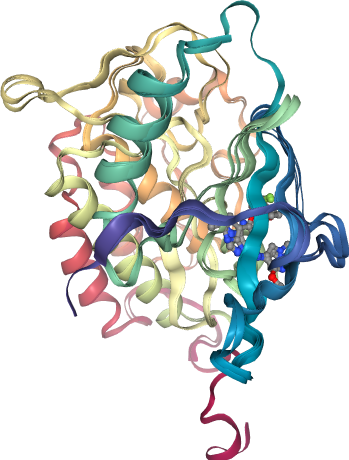

In [33]:
view._display_image()

#### 提取配体

In [34]:
ligands = [
    Structure.from_atomgroup(complex_.select_atoms(f"resname {ligand}"))
    for complex_, ligand in zip(complexes, pairs.values())
]
ligands

[<Universe with 32 atoms>,
 <Universe with 28 atoms>,
 <Universe with 30 atoms>,
 <Universe with 30 atoms>]

In [35]:
for ligand, pdb_id in zip(ligands, pairs.keys()):
    ligand.write(DATA / f"{pdb_id}_lig.pdb")

我们检查所有配体 *pdb* 文件是否存在。

In [36]:
ligand_files = []
for file in DATA.glob("*_lig.pdb"):
    ligand_files.append(file.name)
ligand_files

['5HG8_lig.pdb', '5UG8_lig.pdb', '5UG9_lig.pdb', '5UGC_lig.pdb']

我们也可以使用 `nglview` 来单独描述共晶化配体。正如我们所看到的，选定的复合物包含与 Met793 相互作用（至少接近）的配体，这代表了 EGFR 的正构保守铰链残基（与 Met769 同义）。

In [37]:
view = nglview.NGLWidget()
for component_id, ligand in enumerate(ligands):
    view.add_component(ligand.atoms)
    view.remove_ball_and_stick(component=component_id)
    view.add_licorice(component=component_id)
view

NGLWidget()

In [38]:
view.render_image(trim=True, factor=2, transparent=True);

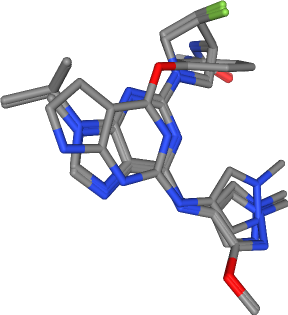

In [39]:
view._display_image()

## 讨论

在本教程中，我们学习了如何使用 Python API 从 PDB 中检索蛋白质和配体元信息以及结构信息。PDB 不仅限于此处使用的搜索字段；我们鼓励您查看 [RCSB PDB 搜索 API](http://search.rcsb.org/) 页面以了解更多信息。在接下来的教程中，我们将使用这些蛋白质-配体复合物来生成药效团模型，并在我们的 EGFR 化合物数据集上筛选它们。

## 课后思考

1. 总结蛋白质数据库所包含的数据类型。
2. 解释 PDB 中结构的分辨率是什么意思。
3. 我们使用哪些搜索条件来查找感兴趣的结构？